In [3]:
pip install selenium

   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---------------------------------------- 0.1/9.7 MB 1.7 MB/s eta 0:00:06
    --------------------------------------- 0.2/9.7 MB 2.8 MB/s eta 0:00:04
   -- ------------------------------------- 0.7/9.7 MB 5.7 MB/s eta 0:00:02
   --- ------------------------------------ 0.9/9.7 MB 6.0 MB/s eta 0:00:02
   ---- ----------------------------------- 1.0/9.7 MB 4.8 MB/s eta 0:00:02
   -------- ------------------------------- 2.0/9.7 MB 8.5 MB/s eta 0:00:01
   --------- ------------------------------ 2.3/9.7 MB 9.0 MB/s eta 0:00:01
   ---------- ----------------------------- 2.4/9.7 MB 7.4 MB/s eta 0:00:01
   ---------- ----------------------------- 2.4/9.7 MB 7.4 MB/s eta 0:00:01
   ----------- ---------------------------- 2.8/9.7 MB 7.2 MB/s eta 0:00:01
   --------------- ------------------------ 3.7/9.7 MB 8.3 MB/s eta 0:00:01
   --------------------- ------------------ 5.3/9.7 MB 10.8 MB/s eta 0:00:01
   ---------------

In [15]:
import selenium
from selenium import webdriver
from selenium.webdriver.common.by import By
import pandas as pd

In [18]:
# Initialize the webdriver
driver = webdriver.Edge()

# Open the target webpage
driver.get("https://www.nseindia.com/market-data/pre-open-market-cm-and-emerge-market")

In [19]:
# Find the table headers
th_elements = driver.find_elements(By.TAG_NAME, "th")
headers = [th.text.strip() for th in th_elements if th.text.strip()]

# Print the headers
print("Headers:", headers)

Headers: ['SYMBOL', 'PREV. CLOSE', 'IEP', 'CHNG', '%CHNG', 'FINAL', 'FINAL\nQUANTITY', 'VALUE\n(₹ Crores)', 'FFM CAP\n(₹ Crores)', 'NM 52W H', 'NM 52W L', 'TODAY']


In [20]:
# Find the table data
rows = driver.find_elements(By.XPATH, "//table//tr")

In [21]:
# Initialize an empty list to store row data
table_data = []

# Clean headers (replace newline characters)
clean_headers = [header.replace("\n", " ").strip() for header in headers]

# Loop through each row
for row in rows:
    # Extract cell data for each row
    cells = row.find_elements(By.TAG_NAME, "td")
    cell_data = [cell.text.strip() for cell in cells]
    
    # Skip empty rows
    if not any(cell_data):
        continue
    
    # Remove the first column if it's always empty
    if cell_data[0] == "":
        cell_data = cell_data[1:]
    
    # Ensure row matches the number of headers
    if len(cell_data) == len(clean_headers):
        table_data.append(cell_data)

# Create a DataFrame using pandas
df = pd.DataFrame(table_data, columns=clean_headers)

# Print
print(df.head())


       SYMBOL PREV. CLOSE       IEP   CHNG %CHNG     FINAL FINAL QUANTITY  \
0    RELIANCE    1,266.45  1,322.25  55.80  4.41  1,322.25      10,70,391   
1  ADANIPORTS    1,150.75  1,163.00  12.25  1.06  1,163.00         11,116   
2    ADANIENT    2,427.85  2,450.00  22.15  0.91  2,450.00          4,707   
3   SUNPHARMA    1,763.30  1,779.00  15.70  0.89  1,779.00          9,194   
4         TCS    4,206.30  4,159.90  29.60  0.72  4,159.90         14,176   

  VALUE (₹ Crores) FFM CAP (₹ Crores)  NM 52W H  NM 52W L TODAY  
0           141.53        8,64,415.88  1,608.80  1,201.50        
1             1.29          84,950.59  1,621.40    995.65        
2             1.15          60,495.93  3,743.90  2,025.00        
3             1.64        1,90,813.15  1,960.35  1,290.00        
4             5.90        4,30,201.61  4,592.25  3,591.50        


In [22]:
# Save the DataFrame as a CSV file
df.to_csv("12_indian_indices.csv", index=False)

# Close the browser
driver.quit()

# Confirm the saved CSV data
print("Data saved to 'updated_indian_indices.csv'")

Data saved to 'updated_indian_indices.csv'


In [23]:
df = df.iloc[:, :-1]

In [25]:
# Strip spaces from all object columns
df['SYMBOL'] = df['SYMBOL'].str.strip()

# Function to clean columns with commas and convert them to numeric types
def clean_column(column):
    if column.dtype == 'object':
        # Remove commas and trim spaces
        column = column.replace({',': ''}, regex=True).str.strip()
    return column

# Apply cleaning to all columns
df = df.apply(clean_column)

# Convert columns to appropriate data types
numeric_columns = [
    'FINAL QUANTITY', 'PREV. CLOSE', 'IEP', 'CHNG', '%CHNG', 
    'FINAL', 'VALUE (₹ Crores)', 'FFM CAP (₹ Crores)', 'NM 52W H','NM 52W L'
]
df.columns = df.columns.str.strip()  # Strip spaces from column names

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')  # Convert to numeric, coerce errors to NaN

# Verify the data types
print(df.dtypes)

# Optional: Handle missing values (if needed)
# For example, fill NaNs with 0 or another placeholder
df = df.fillna(0)


SYMBOL                 object
PREV. CLOSE           float64
IEP                   float64
CHNG                  float64
%CHNG                 float64
FINAL                 float64
FINAL QUANTITY          int64
VALUE (₹ Crores)      float64
FFM CAP (₹ Crores)    float64
NM 52W H              float64
NM 52W L              float64
dtype: object


In [26]:
df.head()

,SYMBOL,PREV. CLOSE,IEP,CHNG,%CHNG,FINAL,FINAL QUANTITY,VALUE (₹ Crores),FFM CAP (₹ Crores),NM 52W H,NM 52W L
0,RELIANCE,1266.45,1322.25,55.80,4.41,1322.25,1070391,141.53,864415.88,1608.80,1201.50
1,ADANIPORTS,1150.75,1163.00,12.25,1.06,1163.00,11116,1.29,84950.59,1621.40,995.65
2,ADANIENT,2427.85,2450.00,22.15,0.91,2450.00,4707,1.15,60495.93,3743.90,2025.00
3,SUNPHARMA,1763.30,1779.00,15.70,0.89,1779.00,9194,1.64,190813.15,1960.35,1290.00
4,TCS,4206.30,4159.90,29.60,0.72,4159.90,14176,5.90,430201.61,4592.25,3591.50


In [27]:
df

,SYMBOL,PREV. CLOSE,IEP,CHNG,%CHNG,FINAL,FINAL QUANTITY,VALUE (₹ Crores),FFM CAP (₹ Crores),NM 52W H,NM 52W L
0,RELIANCE,1266.45,1322.25,55.80,4.41,1322.25,1070391,141.53,864415.88,1608.80,1201.50
1,ADANIPORTS,1150.75,1163.00,12.25,1.06,1163.00,11116,1.29,84950.59,1621.40,995.65
2,ADANIENT,2427.85,2450.00,22.15,0.91,2450.00,4707,1.15,60495.93,3743.90,2025.00
3,SUNPHARMA,1763.30,1779.00,15.70,0.89,1779.00,9194,1.64,190813.15,1960.35,1290.00
4,TCS,4206.30,4159.90,29.60,0.72,4159.90,14176,5.90,430201.61,4592.25,3591.50
5,BPCL,266.90,268.80,1.90,0.71,268.80,25240,0.68,51832.22,376.00,230.05
6,GRASIM,2350.70,2363.10,12.40,0.53,2363.10,249,0.06,87542.61,2877.75,2016.55
7,NESTLEIND,2169.30,2180.65,11.35,0.52,2180.65,510,0.11,77758.19,2778.00,2145.40
8,LT,3507.90,3524.00,16.10,0.46,3524.00,1781,0.63,413260.33,3963.50,3175.05
9,TATACONSUM,937.70,942.00,4.30,0.46,942.00,636,0.06,60934.00,1256.44,882.90


In [55]:
# Drop the row where SYMBOL contains "Total"
df_filtered = df[~df['SYMBOL'].str.contains('Total', case=False, na=False)]


In [56]:
# Top 10 stocks by volume
top_volume = df.nlargest(10, 'FINAL QUANTITY')
print(top_volume[['SYMBOL', 'FINAL QUANTITY']])

        SYMBOL  FINAL QUANTITY
0     RELIANCE         1070391
49        INFY          261998
48    AXISBANK          223795
44    HDFCBANK          157880
19   TATASTEEL           53503
42   ICICIBANK           46995
33       WIPRO           44812
37         BEL           42988
41        ONGC           30594
31  TATAMOTORS           28962


In [57]:
# Top 10 stocks by percentage change
top_pct_chg = df.nlargest(10, '%CHNG')
print(top_pct_chg[['SYMBOL', '%CHNG']])

       SYMBOL  %CHNG
0    RELIANCE   4.41
1  ADANIPORTS   1.06
2    ADANIENT   0.91
3   SUNPHARMA   0.89
4         TCS   0.72
5        BPCL   0.71
6      GRASIM   0.53
7   NESTLEIND   0.52
8          LT   0.46
9  TATACONSUM   0.46


In [58]:
# Top 10 stocks by absolute change
top_chg = df.nlargest(10, 'CHNG')
print(top_chg[['SYMBOL', 'CHNG']])

        SYMBOL   CHNG
0     RELIANCE  55.80
11  APOLLOHOSP  30.30
4          TCS  29.60
2     ADANIENT  22.15
8           LT  16.10
3    SUNPHARMA  15.70
6       GRASIM  12.40
1   ADANIPORTS  12.25
7    NESTLEIND  11.35
10  ASIANPAINT  10.05


In [59]:
# Top 10 stocks by absolute change
top_chg = df.nlargest(10, 'VALUE (₹ Crores)')
print(top_chg[['SYMBOL', 'VALUE (₹ Crores)']])

        SYMBOL  VALUE (₹ Crores)
0     RELIANCE            141.53
49        INFY             48.50
44    HDFCBANK             25.95
48    AXISBANK             22.38
4          TCS              5.90
42   ICICIBANK              5.84
32     HCLTECH              3.10
31  TATAMOTORS              2.24
3    SUNPHARMA              1.64
23        SBIN              1.52


In [60]:
# Exclude rows where the SYMBOL is "Total"
df = df[df['SYMBOL'] != 'Total']

# Stock with the highest volume
highest_volume = df.loc[df['FINAL QUANTITY'].idxmax()]
print(f"Stock with highest volume: {highest_volume['SYMBOL']} with volume {highest_volume['FINAL QUANTITY']}")

Stock with highest volume: RELIANCE with volume 1070391


In [61]:
# Top 10 stocks by PREV. CLOSE
top_volume = df.nlargest(10, 'PREV. CLOSE')

# Print the top 10 stocks by volume
print(top_volume[['SYMBOL', 'PREV. CLOSE']])

        SYMBOL  PREV. CLOSE
18      MARUTI     12092.30
25  ULTRACEMCO     10636.20
35  BAJAJ-AUTO      8581.95
45  BAJFINANCE      7259.75
11  APOLLOHOSP      6789.65
17       TRENT      6211.55
47   EICHERMOT      5047.80
22   BRITANNIA      4844.55
4          TCS      4206.30
20  HEROMOTOCO      4074.10


In [62]:
import matplotlib.pyplot as plt
import seaborn as sns


C:\Users\Acer\AppData\Local\Temp\ipykernel_12672\2518582732.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='FINAL QUANTITY', y='SYMBOL', data=top_volume, palette='viridis')


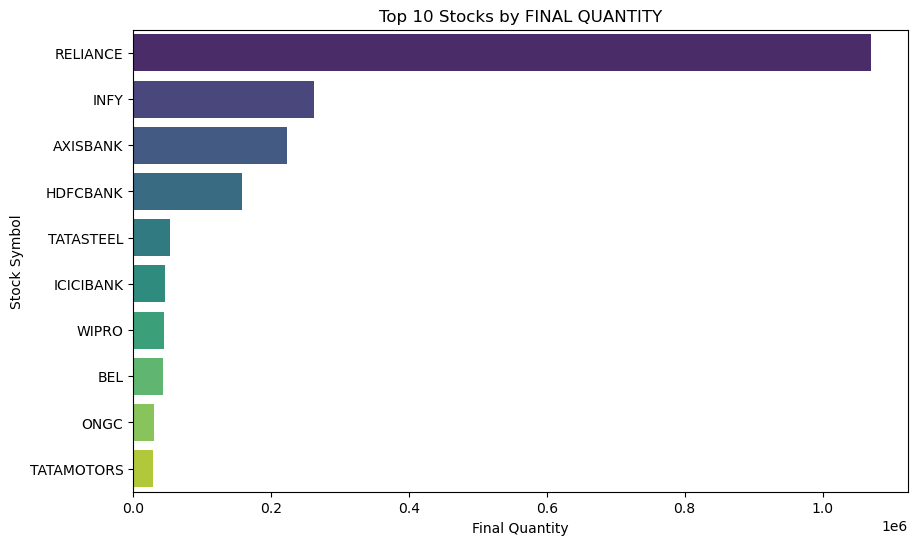

In [78]:

# Get the top 10 stocks by FINAL QUANTITY
top_volume = df_filtered.nlargest(10, 'FINAL QUANTITY')

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x='FINAL QUANTITY', y='SYMBOL', data=top_volume, palette='viridis')
plt.title('Top 10 Stocks by FINAL QUANTITY')
plt.xlabel('Final Quantity')
plt.ylabel('Stock Symbol')
plt.show()

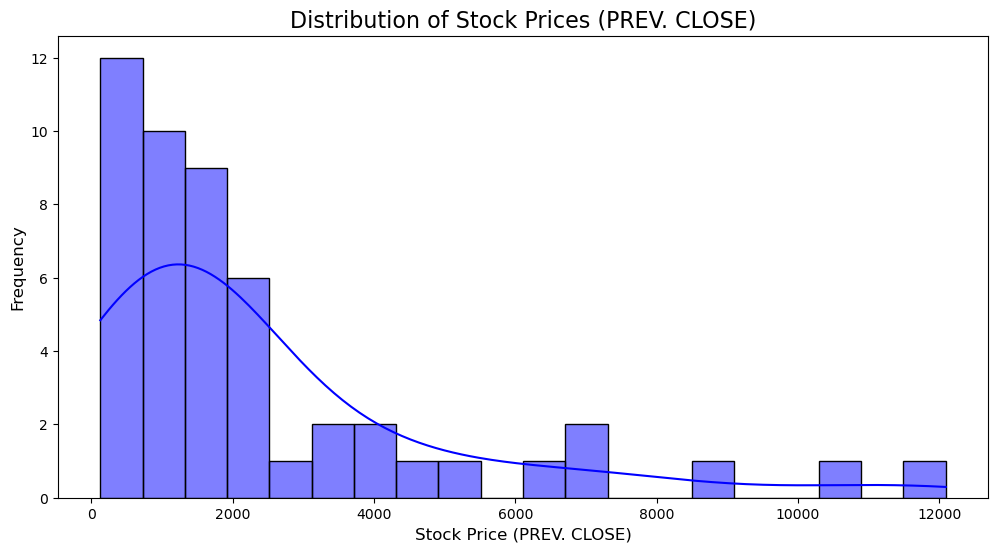

In [65]:
plt.figure(figsize=(12, 6))
sns.histplot(df['PREV. CLOSE'], kde=True, color='blue', bins=20)
plt.title('Distribution of Stock Prices (PREV. CLOSE)', fontsize=16)
plt.xlabel('Stock Price (PREV. CLOSE)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()


C:\Users\Acer\AppData\Local\Temp\ipykernel_12672\3338117802.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_pct_chg, x='SYMBOL', y='%CHNG', palette='coolwarm')


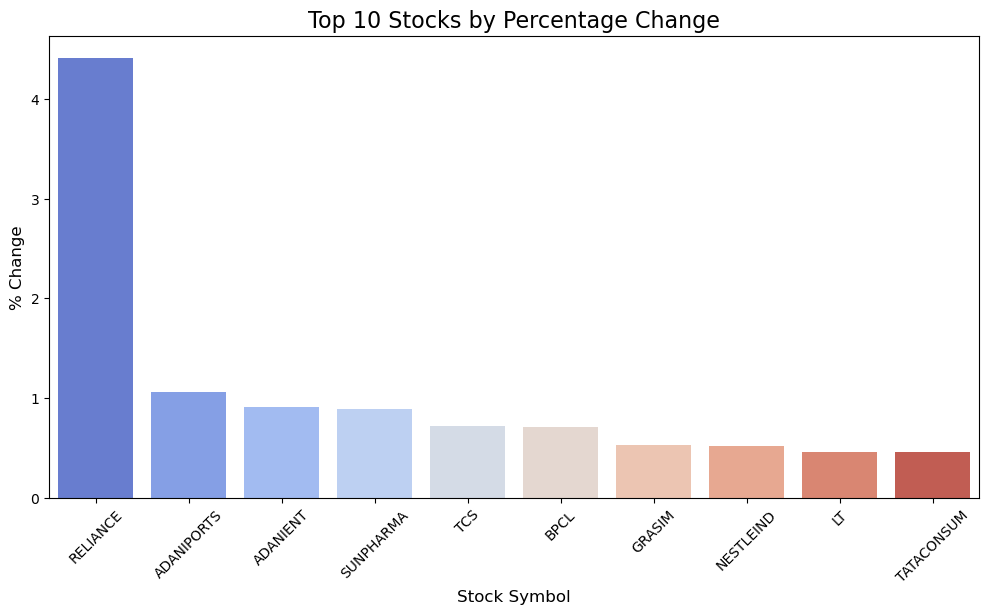

In [66]:
plt.figure(figsize=(12, 6))
top_pct_chg = df.nlargest(10, '%CHNG')
sns.barplot(data=top_pct_chg, x='SYMBOL', y='%CHNG', palette='coolwarm')
plt.title('Top 10 Stocks by Percentage Change', fontsize=16)
plt.xlabel('Stock Symbol', fontsize=12)
plt.ylabel('% Change', fontsize=12)
plt.xticks(rotation=45)
plt.show()



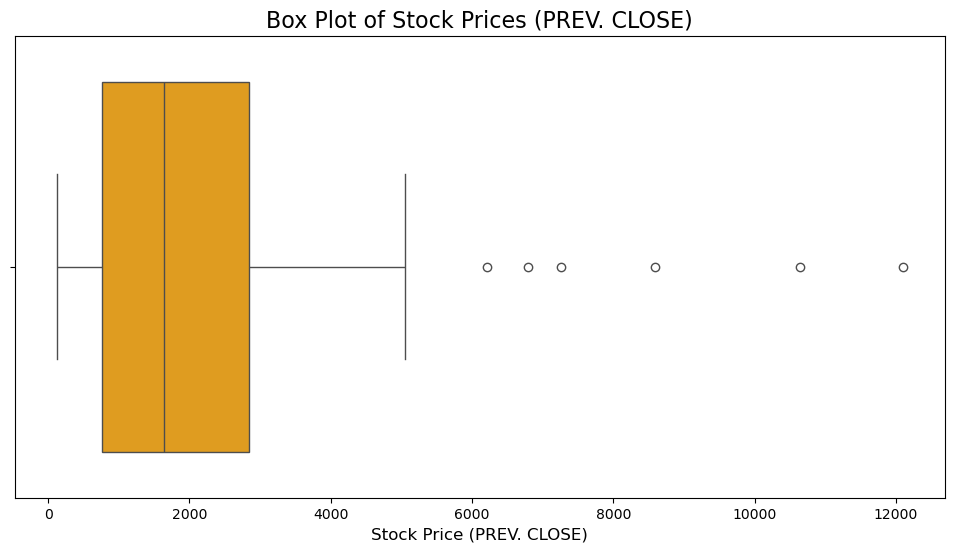

In [67]:
plt.figure(figsize=(12, 6))
sns.boxplot(x=df['PREV. CLOSE'], color='orange')
plt.title('Box Plot of Stock Prices (PREV. CLOSE)', fontsize=16)
plt.xlabel('Stock Price (PREV. CLOSE)', fontsize=12)
plt.show()


C:\Users\Acer\AppData\Local\Temp\ipykernel_12672\870249094.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_value, x='SYMBOL', y='VALUE (₹ Crores)', palette='Blues')


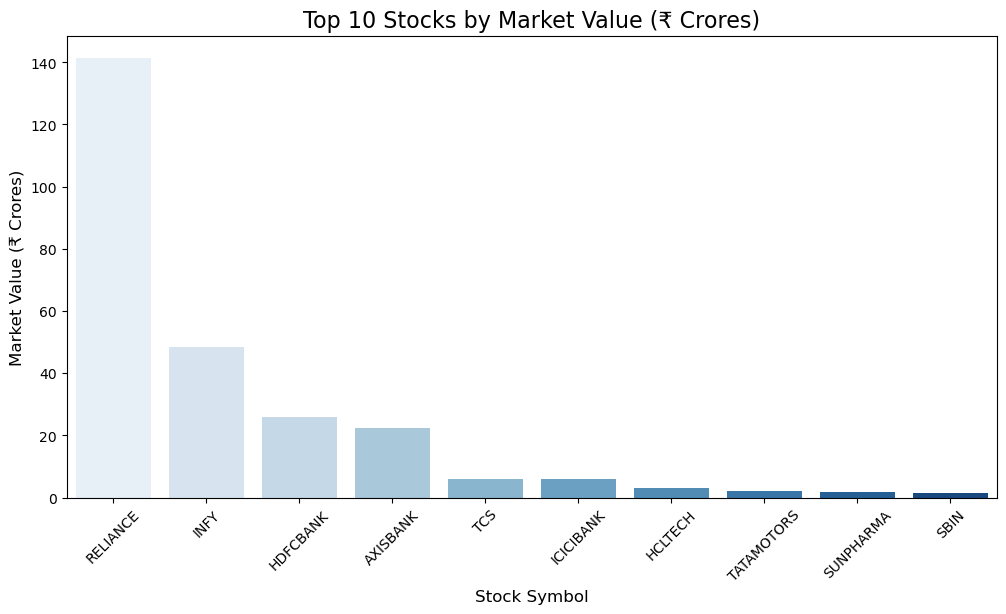

In [68]:
plt.figure(figsize=(12, 6))
top_value = df.nlargest(10, 'VALUE (₹ Crores)')
sns.barplot(data=top_value, x='SYMBOL', y='VALUE (₹ Crores)', palette='Blues')
plt.title('Top 10 Stocks by Market Value (₹ Crores)', fontsize=16)
plt.xlabel('Stock Symbol', fontsize=12)
plt.ylabel('Market Value (₹ Crores)', fontsize=12)
plt.xticks(rotation=45)
plt.show()


C:\Users\Acer\AppData\Local\Temp\ipykernel_12672\3299543433.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_final, x='SYMBOL', y='FINAL', palette='viridis')


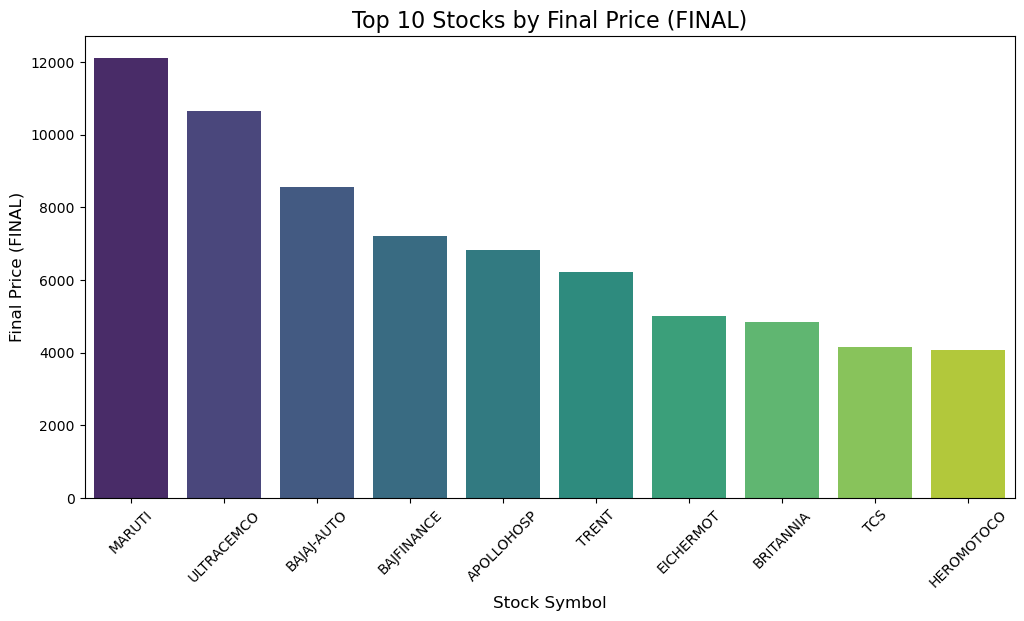

In [69]:
plt.figure(figsize=(12, 6))
top_final = df.nlargest(10, 'FINAL')
sns.barplot(data=top_final, x='SYMBOL', y='FINAL', palette='viridis')
plt.title('Top 10 Stocks by Final Price (FINAL)', fontsize=16)
plt.xlabel('Stock Symbol', fontsize=12)
plt.ylabel('Final Price (FINAL)', fontsize=12)
plt.xticks(rotation=45)
plt.show()



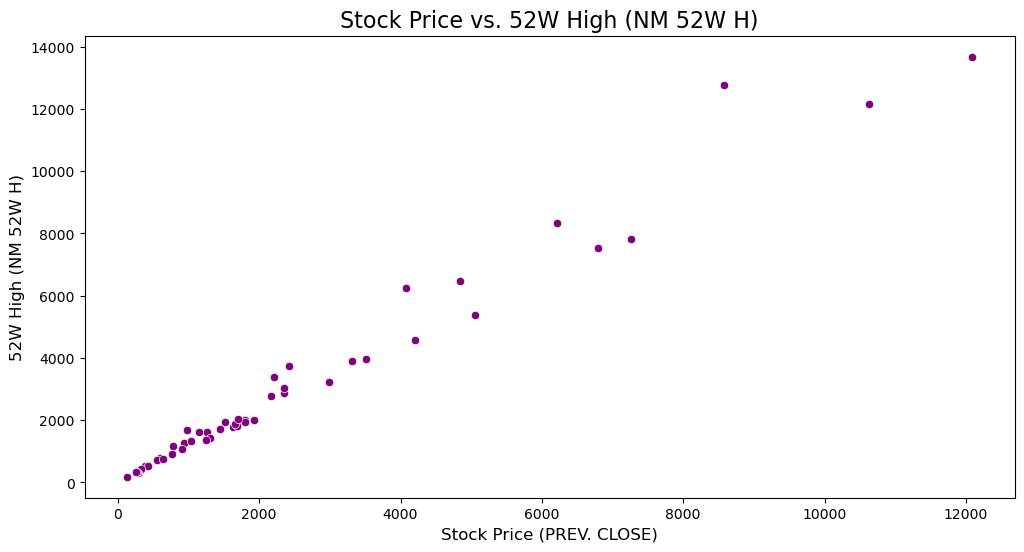

In [70]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='PREV. CLOSE', y='NM 52W H', color='purple')
plt.title('Stock Price vs. 52W High (NM 52W H)', fontsize=16)
plt.xlabel('Stock Price (PREV. CLOSE)', fontsize=12)
plt.ylabel('52W High (NM 52W H)', fontsize=12)
plt.show()



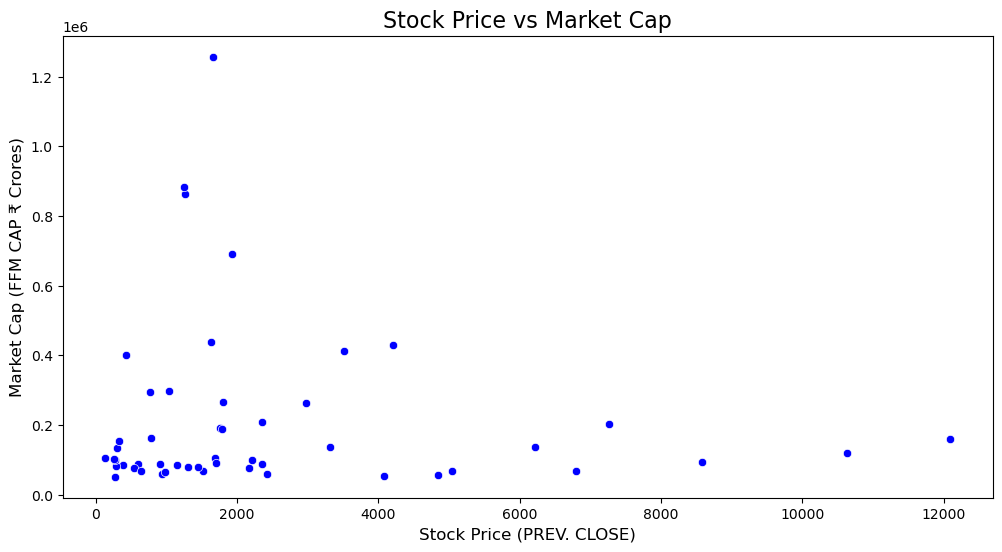

In [76]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='PREV. CLOSE', y='FFM CAP (₹ Crores)', color='blue')
plt.title('Stock Price vs Market Cap', fontsize=16)
plt.xlabel('Stock Price (PREV. CLOSE)', fontsize=12)
plt.ylabel('Market Cap (FFM CAP ₹ Crores)', fontsize=12)
plt.show()

C:\Users\Acer\AppData\Local\Temp\ipykernel_12672\1857124354.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_52w_diff, x='SYMBOL', y='52W High/Low', palette='coolwarm')


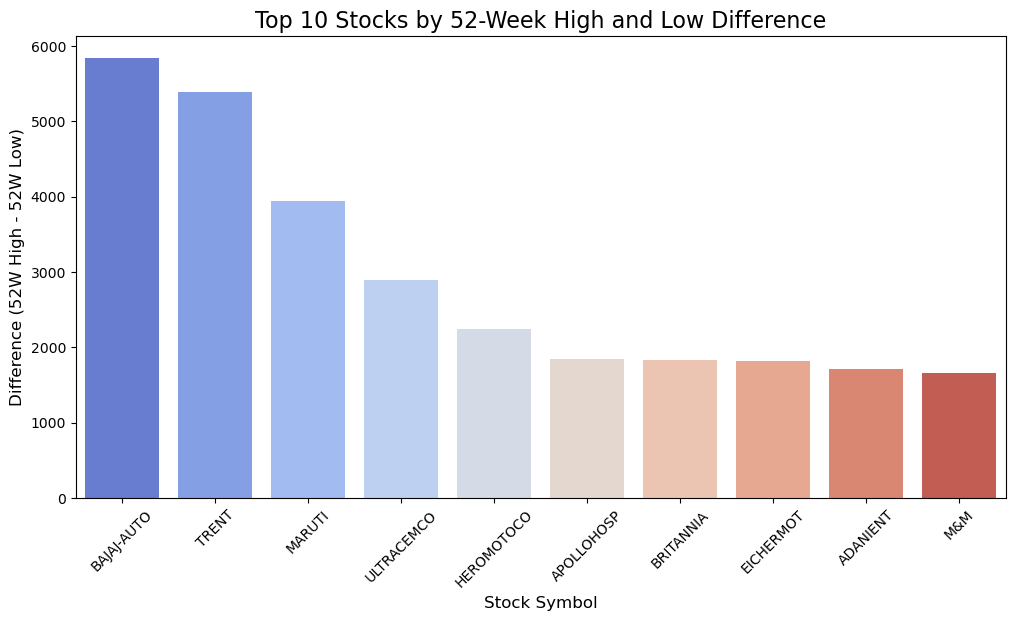

In [77]:
# Calculate the difference between 52-week High and Low
df['52W High/Low'] = df['NM 52W H'] - df['NM 52W L']

# Get the top 10 companies with the largest difference between 52W High and Low
top_10_52w_diff = df.nlargest(10, '52W High/Low')

# Plotting
plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_52w_diff, x='SYMBOL', y='52W High/Low', palette='coolwarm')
plt.title('Top 10 Stocks by 52-Week High and Low Difference', fontsize=16)
plt.xlabel('Stock Symbol', fontsize=12)
plt.ylabel('Difference (52W High - 52W Low)', fontsize=12)
plt.xticks(rotation=45)
plt.show()